In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.chdir("..") 
print("CWD:", os.getcwd()) 

CWD: /Users/oliver/Desktop/BitcoinGraphClassification


Sizes  train/val/test: 245667 / 33389 / 88416
Class counts (train): [225742  19925]
Class counts (val)  : [29734  3655]
Class counts (test) : [83395  5021]

Grid search (train ≤34, validate 35–39) ...
  300 trees, depth=None, mss=2, msl=1, mf=sqrt -> Val PR-AUC=0.7109
  600 trees, depth=None, mss=2, msl=1, mf=sqrt -> Val PR-AUC=0.7204
  300 trees, depth=None, mss=5, msl=1, mf=sqrt -> Val PR-AUC=0.7230
  600 trees, depth=None, mss=5, msl=1, mf=sqrt -> Val PR-AUC=0.7092
  300 trees, depth=None, mss=2, msl=2, mf=sqrt -> Val PR-AUC=0.7445
  600 trees, depth=None, mss=2, msl=2, mf=sqrt -> Val PR-AUC=0.7469
  300 trees, depth=None, mss=5, msl=2, mf=sqrt -> Val PR-AUC=0.7455
  600 trees, depth=None, mss=5, msl=2, mf=sqrt -> Val PR-AUC=0.7507
  300 trees, depth=None, mss=2, msl=1, mf=log2 -> Val PR-AUC=0.7749
  600 trees, depth=None, mss=2, msl=1, mf=log2 -> Val PR-AUC=0.7770
  300 trees, depth=None, mss=5, msl=1, mf=log2 -> Val PR-AUC=0.7798
  600 trees, depth=None, mss=5, msl=1, mf=log2 -> V

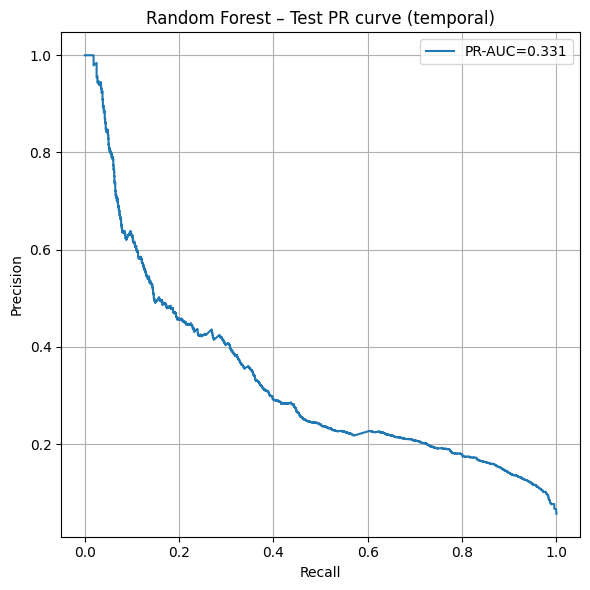

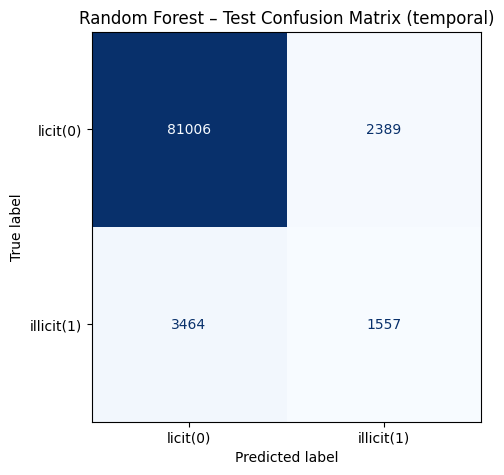

Saved: results/rf_importances_{gini, permutation, merged}.csv


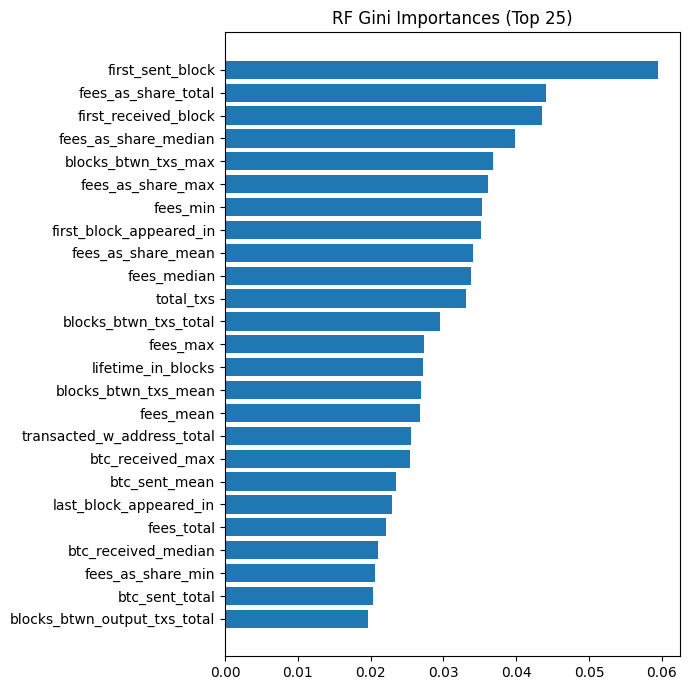

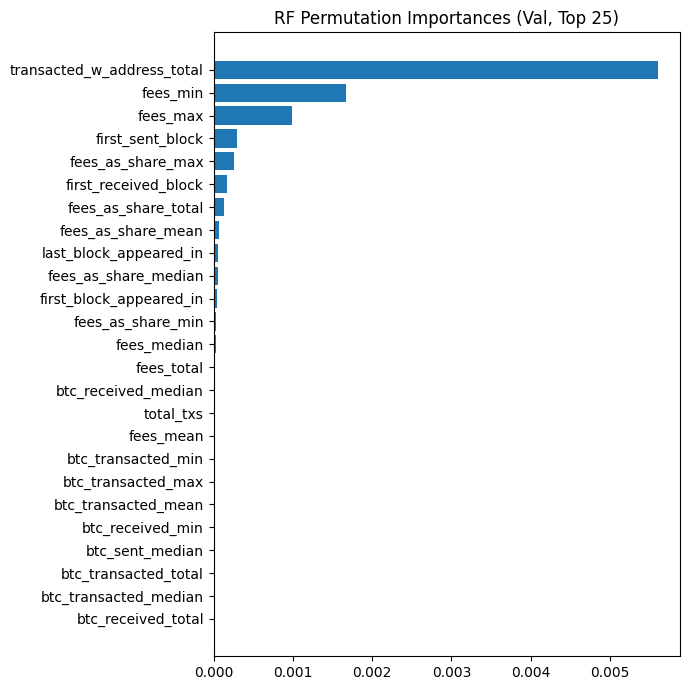

Saved: results/feature_rankings.json


In [ ]:
# Random Forest (temporal + robust importances)
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, average_precision_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from joblib import parallel_backend  # <- use threads instead of processes (macOS 3.13 noise fix)

os.makedirs("results", exist_ok=True)

df = pd.read_csv("data/raw/wallets_features_classes_combined.csv")
df = df[df["class"].isin([1, 2])].copy()              # keep licit(2) / illicit(1)
y_all = df["class"].map({2: 0, 1: 1}).to_numpy()      # 0=licit, 1=illicit

drop_cols = ["address", "class", "node_id", "Time step"]
feat_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feat_cols].to_numpy(dtype=np.float32)

# temporal splits (match experimental protocol) 
t_train_max = 34
t_val_min, t_val_max = 35, 39
t_test_min = 40

ts = df["Time step"].to_numpy()
idx_train = np.where(ts <= t_train_max)[0]
idx_val   = np.where((ts >= t_val_min) & (ts <= t_val_max))[0]
idx_test  = np.where(ts >= t_test_min)[0]

#  standardize on TRAIN only (RF doesn't need it, keeps parity with GNN) 
X_all[idx_train] = scaler.fit_transform(X_all[idx_train])
X_all[idx_val]   = scaler.transform(X_all[idx_val])
X_all[idx_test]  = scaler.transform(X_all[idx_test])

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val,   y_val   = X_all[idx_val],   y_all[idx_val]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"Sizes  train/val/test: {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")
print("Class counts (train):", np.bincount(y_train))
print("Class counts (val)  :", np.bincount(y_val))
print("Class counts (test) :", np.bincount(y_test))

# grid (PR-AUC on validation)
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 24, 36],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"],
    "random_state": [420],
    "n_jobs": [-1],  
}

best = {"pr_auc": -1.0, "params": None}

print("\nGrid search (train ≤34, validate 35–39) ...")
# NOTE: using threading backend avoids noisy 'no child processes' messages on macOS + Python 3.13
with parallel_backend("threading"):
    for params in ParameterGrid(param_grid):
        clf = RandomForestClassifier(**params)
        clf.fit(X_train, y_train)
        y_val_prob = clf.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, y_val_prob)
        if pr_auc > best["pr_auc"]:
            best = {"pr_auc": pr_auc, "params": params}
        print(f"  {params['n_estimators']:>3} trees, depth={params['max_depth']}, "
              f"mss={params['min_samples_split']}, msl={params['min_samples_leaf']}, "
              f"mf={params['max_features']} -> Val PR-AUC={pr_auc:.4f}")

print(f"\nBest params (Val PR-AUC={best['pr_auc']:.4f}):\n{best['params']}")

# pick decision threshold on VAL using a model trained on TRAIN only (no leakage) 

with parallel_backend("threading"):
    clf_for_thr = RandomForestClassifier(**best["params"])
    clf_for_thr.fit(X_train, y_train)
    y_val_prob_for_thr = clf_for_thr.predict_proba(X_val)[:, 1]

grid_thr = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_val, (y_val_prob_for_thr >= t).astype(int), average="macro") for t in grid_thr]
best_thr = float(grid_thr[int(np.argmax(f1s))])

# retrain on TRAIN+VAL, evaluate on TEST
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

with parallel_backend("threading"):
    final_clf = RandomForestClassifier(**best["params"])
    final_clf.fit(X_trainval, y_trainval)
    y_test_prob = final_clf.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_prob >= best_thr).astype(int)
test_acc  = accuracy_score(y_test, y_test_pred)
test_f1   = f1_score(y_test, y_test_pred, average="macro")
test_pra  = average_precision_score(y_test, y_test_prob)

print("\n=== TEST (≥40) ===")
print(f"Accuracy      : {test_acc:.4f}")
print(f"Macro F1      : {test_f1:.4f}")
print(f"PR-AUC        : {test_pra:.4f}")
print(f"Chosen thresh : {best_thr:.2f}  (picked on VAL; model trained on TRAIN only)")

# save summary
out_row = pd.DataFrame([{
    "best_params": best["params"],
    "threshold": best_thr,
    "test_acc": test_acc,
    "test_f1": test_f1,
    "test_pr_auc": test_pra,
}])
out_csv = "results/rf_temporal_results.csv"
out_row.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# PR curve (test)
prec_t, rec_t, _ = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6,6))
plt.plot(rec_t, prec_t, label=f"PR-AUC={test_pra:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Random Forest – Test PR curve (temporal)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("results/rf_precision_recall_curve_temporal.pdf")
plt.show(); plt.close('all')  # close figures (keeps memory + avoids backend weirdness)

# Conf. matrix 
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1], normalize=None)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["licit(0)","illicit(1)"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest – Test Confusion Matrix (temporal)")
plt.tight_layout()
plt.savefig("results/rf_confusion_matrix_temporal.pdf")
plt.show(); plt.close('all')

# importances: Gini + Permutation (val) 
# Why? Gini is fast but biased to high-cardinality/continuous permutation is slower but task-aligned (PR-AUC).
gini_series = pd.Series(final_clf.feature_importances_, index=feat_cols).sort_values(ascending=False)
gini_df = (gini_series
           .rename("gini_importance")
           .reset_index()
           .rename(columns={"index": "feature"}))
gini_df["rank_gini"] = np.arange(1, len(gini_df) + 1)
gini_df["cum_importance"] = gini_df["gini_importance"].cumsum()

# perm-importance on validation 
with parallel_backend("threading"):
    perm = permutation_importance(
        final_clf, X_val, y_val,
        scoring="average_precision",
        n_repeats=5, random_state=420, n_jobs=-1
    )
perm_df = (pd.DataFrame({
    "feature": feat_cols,
    "perm_mean": perm.importances_mean,
    "perm_std":  perm.importances_std
}).sort_values("perm_mean", ascending=False).reset_index(drop=True))
perm_df["rank_perm"] = np.arange(1, len(perm_df) + 1)

# Merge views and save
imp_merged = gini_df.merge(perm_df, on="feature", how="outer").fillna(0.0)
imp_merged.to_csv("results/rf_importances_merged.csv", index=False)
gini_df.to_csv("results/rf_importances_gini.csv", index=False)
perm_df.to_csv("results/rf_importances_permutation_val.csv", index=False)
print("Saved: results/rf_importances_{gini, permutation, merged}.csv")

# Plot top-25 
plt.figure(figsize=(7,7))
tmp = gini_df.head(25).iloc[::-1]
plt.barh(tmp["feature"], tmp["gini_importance"])
plt.title("RF Gini Importances (Top 25)")
plt.tight_layout()
plt.savefig("results/rf_importances_gini_top25.pdf")
plt.show(); plt.close('all')

plt.figure(figsize=(7,7))
tmp = perm_df.head(25).iloc[::-1]
plt.barh(tmp["feature"], tmp["perm_mean"])
plt.title("RF Permutation Importances (Val, Top 25)")
plt.tight_layout()
plt.savefig("results/rf_importances_perm_top25.pdf")
plt.show(); plt.close('all')

# exporting top-K feature sets for GNN ablations
feat_rank_gini = gini_df["feature"].tolist()
feat_rank_perm = perm_df["feature"].tolist()
name_to_idx = {name: i for i, name in enumerate(feat_cols)}

topK = [20, 30, 40, len(feat_cols)]
packs = {}
for K in topK:
    packs[f"gini_top_{K}"] = feat_rank_gini[:K]
    packs[f"perm_top_{K}"] = feat_rank_perm[:K]

# provide index lists 
packs_idx = {k: [name_to_idx[n] for n in v] for k, v in packs.items()}

with open("results/feature_rankings.json", "w") as f:
    json.dump({"by_name": packs, "by_index": packs_idx, "all_features": feat_cols}, f, indent=2)
print("Saved: results/feature_rankings.json")

Saved: results/rf_test_time_metrics.csv


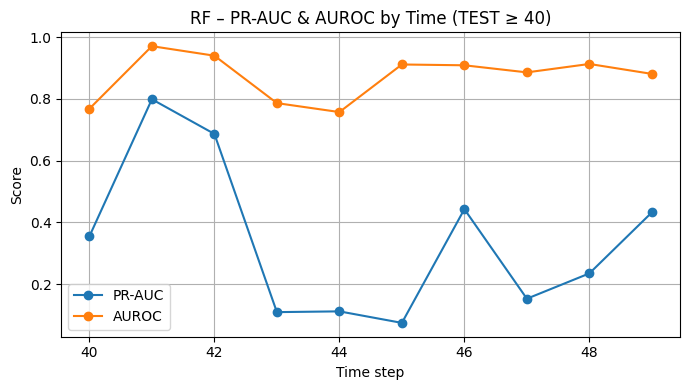

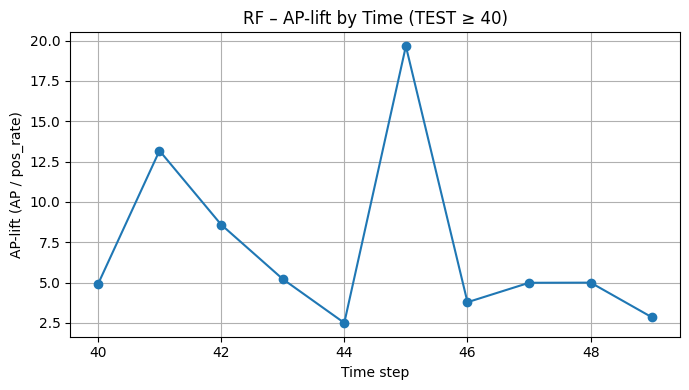

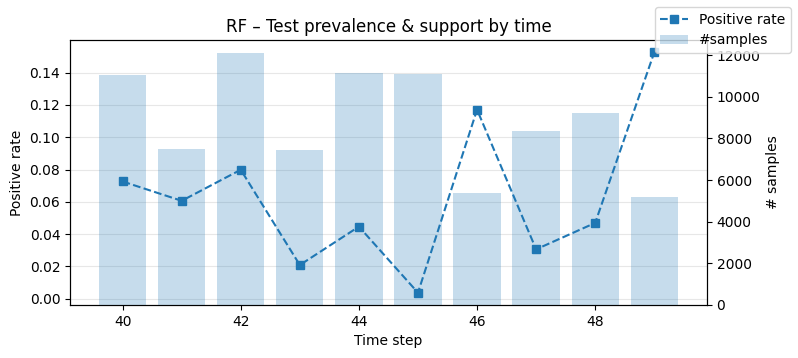

In [ ]:
#  Per-time metrics (TEST): PR-AUC, AUROC, AP-lift, prevalence
# why: PR-AUC is prevalence-sensitive; AUROC sanity-checks ranking skill;
#      AP-lift = AP / prevalence normalizes AP by the trivial baseline.

ts_test = ts[idx_test]  # time step per test node
rows = []
for t in np.unique(ts_test):
    m = (ts_test == t)
    y_t = y_test[m]
    p_t = y_test_prob[m]
    n = int(m.sum())
    if n == 0:
        continue
    prev = float(y_t.mean())  # positive rate
    # need both classes to compute PR-AUC/AUROC
    if y_t.max() != y_t.min():
        pra  = average_precision_score(y_t, p_t)
        au   = roc_auc_score(y_t, p_t)
        lift = pra / max(prev, 1e-9)
    else:
        pra, au, lift = (np.nan, np.nan, np.nan)
    rows.append({
        "time_step": int(t),
        "n": n,
        "pos_rate": prev,
        "pr_auc": pra,
        "auroc": au,
        "ap_lift": lift,
    })

df_time = pd.DataFrame(rows).sort_values("time_step")
df_time.to_csv("results/rf_test_time_metrics.csv", index=False)
print("Saved: results/rf_test_time_metrics.csv")

plt.figure(figsize=(7,4))
plt.plot(df_time["time_step"], df_time["pr_auc"], marker="o", label="PR-AUC")
plt.plot(df_time["time_step"], df_time["auroc"], marker="o", label="AUROC")
plt.xlabel("Time step"); plt.ylabel("Score")
plt.title("RF – PR-AUC & AUROC by Time (TEST ≥ 40)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig("results/rf_time_pra_auroc.pdf")
plt.show(); plt.close('all')

plt.figure(figsize=(7,4))
plt.plot(df_time["time_step"], df_time["ap_lift"], marker="o")
plt.xlabel("Time step"); plt.ylabel("AP-lift (AP / pos_rate)")
plt.title("RF – AP-lift by Time (TEST ≥ 40)")
plt.grid(True); plt.tight_layout()
plt.savefig("results/rf_time_ap_lift.pdf")
plt.show(); plt.close('all')

fig, ax1 = plt.subplots(figsize=(8,3.6))
ax1.plot(df_time["time_step"], df_time["pos_rate"], marker="s", linestyle="--", label="Positive rate")
ax1.set_xlabel("Time step"); ax1.set_ylabel("Positive rate")
ax1.grid(True, axis="y", alpha=0.3)
ax2 = ax1.twinx()
ax2.bar(df_time["time_step"], df_time["n"], alpha=0.25, label="#samples")
ax2.set_ylabel("# samples")
fig.legend(loc="upper right")
plt.title("RF – Test prevalence & support by time")
plt.tight_layout(); plt.savefig("results/rf_test_prevalence_support_by_time.pdf")
plt.show(); plt.close('all')


xgboost version: 3.0.5
Sizes train/val/test: 245667 / 33389 / 88416
Class counts (train/val/test): [225742  19925] [29734  3655] [83395  5021]
scale_pos_weight ≈ 11.33

Grid (xgb.train with early_stopping_rounds=100) ...
  eta=0.05, depth=4, mcw=1, lambda=1.0 -> Val PR-AUC=0.7444 | best_trees=74
  eta=0.05, depth=4, mcw=1, lambda=5.0 -> Val PR-AUC=0.7495 | best_trees=81
  eta=0.05, depth=4, mcw=5, lambda=1.0 -> Val PR-AUC=0.7444 | best_trees=74
  eta=0.05, depth=4, mcw=5, lambda=5.0 -> Val PR-AUC=0.7495 | best_trees=81
  eta=0.05, depth=6, mcw=1, lambda=1.0 -> Val PR-AUC=0.6758 | best_trees=13
  eta=0.05, depth=6, mcw=1, lambda=5.0 -> Val PR-AUC=0.6761 | best_trees=14
  eta=0.05, depth=6, mcw=5, lambda=1.0 -> Val PR-AUC=0.6758 | best_trees=13
  eta=0.05, depth=6, mcw=5, lambda=5.0 -> Val PR-AUC=0.6761 | best_trees=14
  eta=0.05, depth=8, mcw=1, lambda=1.0 -> Val PR-AUC=0.8429 | best_trees=1997
  eta=0.05, depth=8, mcw=1, lambda=5.0 -> Val PR-AUC=0.8497 | best_trees=1294
  eta=0.05, dep

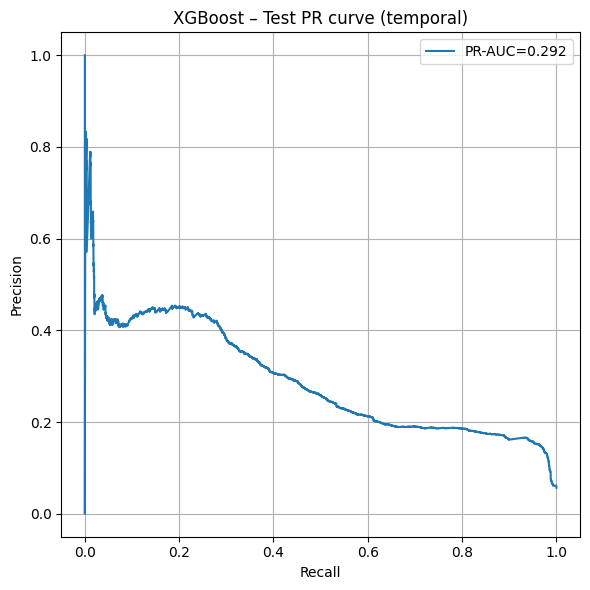

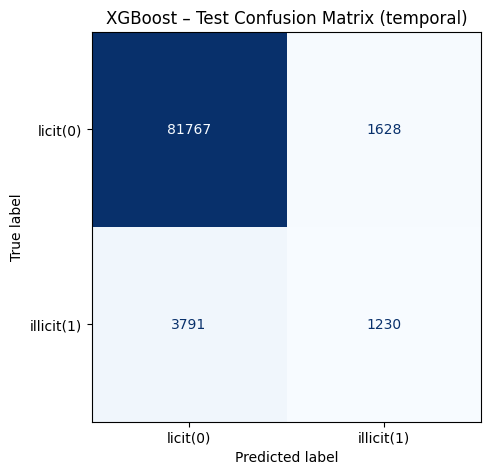

In [ ]:
# XGBoost not used in study; provided for reference
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, average_precision_score,
                             precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay)

import xgboost as xgb
print("xgboost version:", xgb.__version__)
os.makedirs("results", exist_ok=True)

# ---------- load & prepare -----------------------------------------------------
df = pd.read_csv("data/raw/wallets_features_classes_combined.csv")
df = df[df["class"].isin([1, 2])].copy()
y_all = df["class"].map({2: 0, 1: 1}).to_numpy()  # 0=licit, 1=illicit

drop_cols = ["address", "class", "node_id", "Time step"]
feat_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feat_cols].to_numpy(dtype=np.float32)

# temporal split (match your GNN/RF)
t_train_max = 34
t_val_min, t_val_max = 35, 39
t_test_min = 40
ts = df["Time step"].to_numpy()

idx_train = np.where(ts <= t_train_max)[0]
idx_val   = np.where((ts >= t_val_min) & (ts <= t_val_max))[0]
idx_test  = np.where(ts >= t_test_min)[0]

# train-only scaling
scaler = StandardScaler()
X_all[idx_train] = scaler.fit_transform(X_all[idx_train])
X_all[idx_val]   = scaler.transform(X_all[idx_val])
X_all[idx_test]  = scaler.transform(X_all[idx_test])

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val,   y_val   = X_all[idx_val],   y_all[idx_val]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"Sizes train/val/test: {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")
print("Class counts (train/val/test):",
      np.bincount(y_train), np.bincount(y_val), np.bincount(y_test))

# imbalance hint for XGB
pos = max(1, int((y_train == 1).sum()))
neg = max(1, int((y_train == 0).sum()))
scale_pos_weight = max(1.0, neg / pos)
print(f"scale_pos_weight ≈ {scale_pos_weight:.2f}")

# DMatrices
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feat_cols)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=feat_cols)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=feat_cols)
dtrainval = xgb.DMatrix(np.vstack([X_train, X_val]),
                        label=np.concatenate([y_train, y_val]),
                        feature_names=feat_cols)

# helper: robust prediction limited to best trees across XGBoost versions
def predict_best(bst: xgb.Booster, dmat: xgb.DMatrix, best_trees: int | None):
    if best_trees is None:
        return bst.predict(dmat)
    # try modern args
    try:
        return bst.predict(dmat, iteration_range=(0, int(best_trees)))
    except TypeError:
        pass
    try:
        return bst.predict(dmat, iteration_end=int(best_trees))
    except TypeError:
        pass
    # final fallback: use all trees
    return bst.predict(dmat)

# grid + early stopping via xgb.train 
grid = [
    {"eta": lr, "max_depth": md, "min_child_weight": mcw, "lambda": rl,
     "subsample": 0.8, "colsample_bytree": 0.8}
    for lr in [0.05, 0.10]
    for md in [4, 6, 8]
    for mcw in [1, 5]
    for rl in [1.0, 5.0]
]

base_params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",  # PR-AUC
    "tree_method": "hist",
    "scale_pos_weight": scale_pos_weight,
    "verbosity": 0,
    "nthread": -1,
    "seed": 420,
}

best = {"val_pra": -1, "params": None, "best_trees": None}

print("\nGrid (xgb.train with early_stopping_rounds=100) ...")
for p in grid:
    params = base_params.copy()
    params.update(p)

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=[(dval, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    # discover best number of trees across versions
    best_trees = getattr(bst, "best_ntree_limit", None)
    if not best_trees:
        it = getattr(bst, "best_iteration", None)
        if it is not None:
            best_trees = it + 1
    if not best_trees:
        # fallback if object lacks attributes
        try:
            best_trees = bst.num_boosted_rounds()
        except Exception:
            best_trees = 2000

    y_val_prob = predict_best(bst, dval, best_trees)
    val_pra = average_precision_score(y_val, y_val_prob)

    print(f"  eta={p['eta']}, depth={p['max_depth']}, mcw={p['min_child_weight']}, "
          f"lambda={p['lambda']} -> Val PR-AUC={val_pra:.4f} | best_trees={best_trees}")

    if val_pra > best["val_pra"]:
        best["val_pra"] = val_pra
        best["params"]  = p
        best["best_trees"] = int(best_trees)

print("\nBest (validation):", best)

# refit on TRAIN+VAL with best trees 
refit_params = base_params.copy()
refit_params.update(best["params"])

bst_final = xgb.train(
    refit_params,
    dtrainval,
    num_boost_round=int(best["best_trees"]),
    verbose_eval=False,
)

# threshold from validation (macro-F1)
y_val_prob_refit = predict_best(bst_final, dval, best["best_trees"])
thr_grid = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_val, (y_val_prob_refit >= t).astype(int), average="macro") for t in thr_grid]
best_thr = float(thr_grid[int(np.argmax(f1s))])

#test eval
y_test_prob = predict_best(bst_final, dtest, best["best_trees"])
y_test_pred = (y_test_prob >= best_thr).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average="macro")
test_pra = average_precision_score(y_test, y_test_prob)

print("\n=== XGBoost TEST (≥40) ===")
print(f"Accuracy      : {test_acc:.4f}")
print(f"Macro F1      : {test_f1:.4f}")
print(f"PR-AUC        : {test_pra:.4f}")
print(f"Chosen thresh : {best_thr:.2f}")
print("Best params   :", best["params"], "| best trees:", best["best_trees"])

# save summary
pd.DataFrame([{
    "best_params": best["params"],
    "best_trees": int(best["best_trees"]),
    "threshold": best_thr,
    "test_acc": test_acc,
    "test_f1": test_f1,
    "test_pr_auc": test_pra,
}]).to_csv("results/xgb_temporal_results.csv", index=False)
print("Saved: results/xgb_temporal_results.csv")

# plots
prec_t, rec_t, _ = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6,6))
plt.plot(rec_t, prec_t, label=f"PR-AUC={test_pra:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("XGBoost – Test PR curve (temporal)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("results/xgb_pr_curve_temporal.pdf")
plt.show()

cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["licit(0)","illicit(1)"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("XGBoost – Test Confusion Matrix (temporal)")
plt.tight_layout()
plt.savefig("results/xgb_confusion_matrix_temporal.pdf")
plt.show()


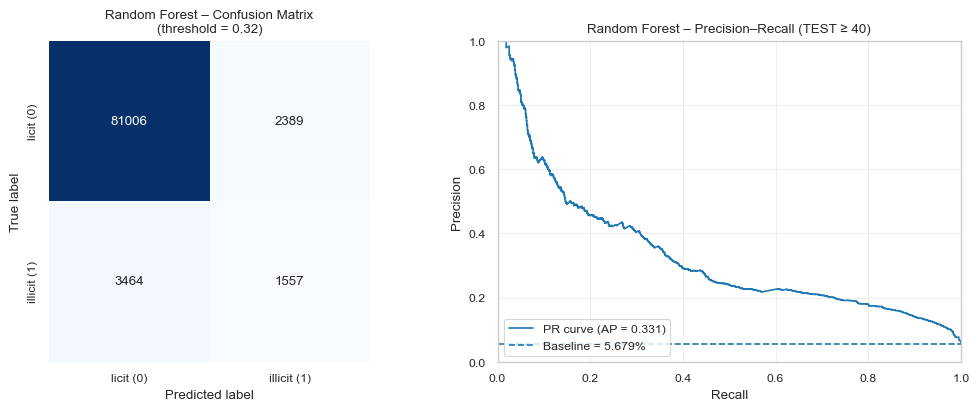

Saved:
  results/rf_cm_prcurve_2x1.pdf
  results/rf_cm_prcurve_2x1.png


In [ ]:
# makes a single 2×1 figure (Confusion Matrix + PR curve) from saved best params 
import os, ast, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, f1_score

sns.set_context("paper")
sns.set_style("whitegrid")  

os.makedirs("results", exist_ok=True)

# 1) load best params + chosen threshold from previous run
best_row = pd.read_csv("results/rf_temporal_results.csv").iloc[-1]
best_params = ast.literal_eval(str(best_row["best_params"]))
best_thr    = float(best_row["threshold"])

# 2) reload data + do the same temporal split + scaling (same as before)
df = pd.read_csv("data/raw/wallets_features_classes_combined.csv")
df = df[df["class"].isin([1, 2])].copy()
y_all = df["class"].map({2: 0, 1: 1}).to_numpy()

drop_cols = ["address", "class", "node_id", "Time step"]
feat_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feat_cols].to_numpy(dtype=np.float32)

t_train_max = 34
t_val_min, t_val_max = 35, 39
t_test_min = 40

ts = df["Time step"].to_numpy()
idx_train = np.where(ts <= t_train_max)[0]
idx_val   = np.where((ts >= t_val_min) & (ts <= t_val_max))[0]
idx_test  = np.where(ts >= t_test_min)[0]

scaler = StandardScaler()
X_all[idx_train] = scaler.fit_transform(X_all[idx_train])
X_all[idx_val]   = scaler.transform(X_all[idx_val])
X_all[idx_test]  = scaler.transform(X_all[idx_test])

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val,   y_val   = X_all[idx_val],   y_all[idx_val]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

# 3) train on TRAIN+VAL once, evaluate on TEST
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

rf = RandomForestClassifier(**best_params)
rf.fit(X_trainval, y_trainval)
p_test = rf.predict_proba(X_test)[:, 1]
y_pred = (p_test >= best_thr).astype(int)

# 4) compute numbers for annotations
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ap = average_precision_score(y_test, p_test)
pos_rate = y_test.mean()

# 5) plot 2×1
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Confusion matrix
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["licit (0)", "illicit (1)"],
            yticklabels=["licit (0)", "illicit (1)"],
            square=True, linewidths=0)
ax.set_title(f"Random Forest – Confusion Matrix\n(threshold = {best_thr:.2f})")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.grid(False)

# PR curve
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_test, p_test)
ax.plot(rec, prec, label=f"PR curve (AP = {ap:.3f})")
ax.hlines(pos_rate, 0, 1, linestyles="--", label=f"Baseline = {pos_rate:.3%}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Random Forest – Precision–Recall (TEST ≥ 40)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

out_pdf = "results/rf_cm_prcurve_2x1.pdf"
out_png = "results/rf_cm_prcurve_2x1.png"
fig.savefig(out_pdf)
fig.savefig(out_png, dpi=200)
plt.show()

print(f"Saved:\n  {out_pdf}\n  {out_png}")


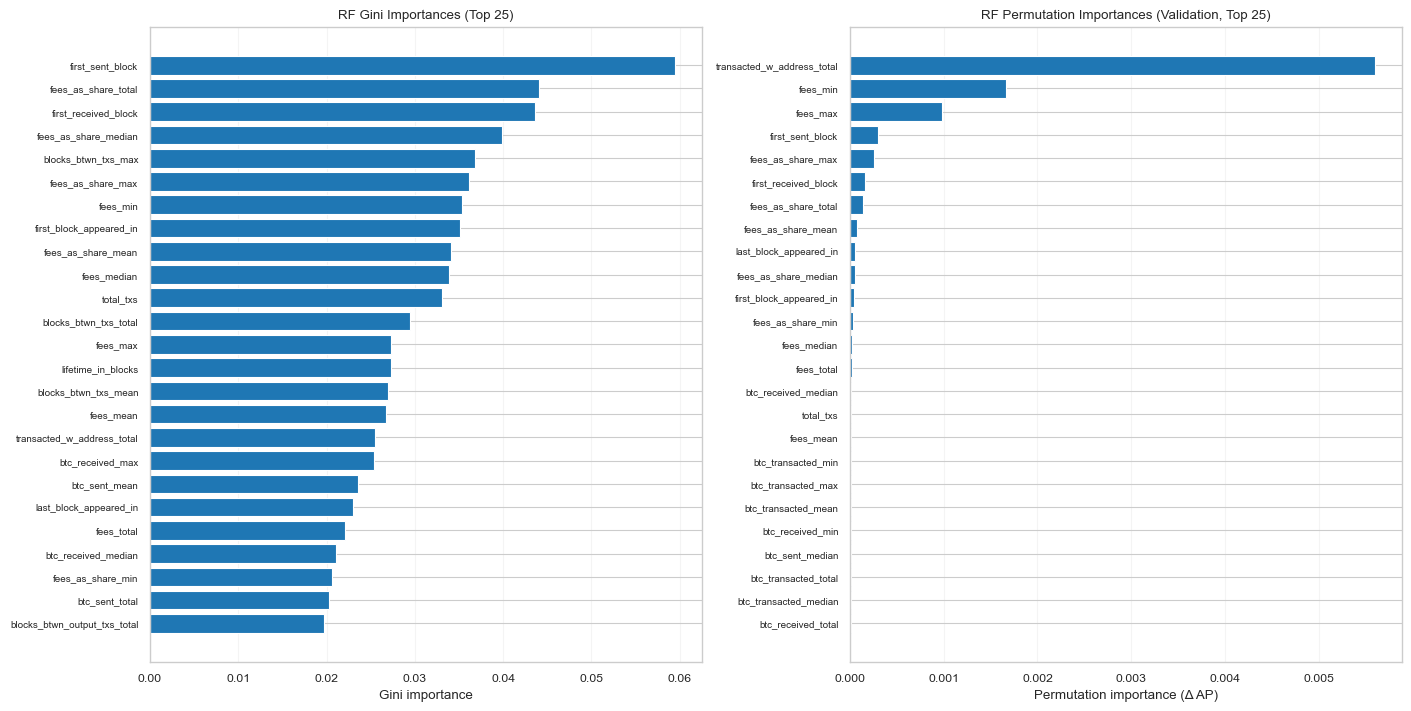

Saved: results/rf_importances_top25_1x2.pdf


In [ ]:
# RF importances: 1×2 grid (Gini, Permutation)
# reads the CSVs saved earlier and replots 

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

gini_csv = "results/rf_importances_gini.csv"
perm_csv = "results/rf_importances_permutation_val.csv"
assert os.path.exists(gini_csv) and os.path.exists(perm_csv), "Run the RF notebook first to create the CSVs."

# Load + prep
gini_df = pd.read_csv(gini_csv).copy()
perm_df = pd.read_csv(perm_csv).copy()

# sort desc, take top-25, reverse for nicer top-to-bottom ordering in barh
gini_top = gini_df.sort_values("gini_importance", ascending=False).head(25).iloc[::-1]
perm_top = perm_df.sort_values("perm_mean",       ascending=False).head(25).iloc[::-1]

# Plot 1×2 (side-by-side)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7), constrained_layout=True)

# (1) Gini
axes[0].barh(gini_top["feature"], gini_top["gini_importance"])
axes[0].set_title("RF Gini Importances (Top 25)")
axes[0].set_xlabel("Gini importance")
axes[0].grid(axis="x", alpha=0.2)
for label in axes[0].get_yticklabels():
    label.set_fontsize(7)

# (2) Permutation (validation AP)
axes[1].barh(perm_top["feature"], perm_top["perm_mean"])
axes[1].set_title("RF Permutation Importances (Validation, Top 25)")
axes[1].set_xlabel("Permutation importance (Δ AP)")
axes[1].grid(axis="x", alpha=0.2)
for label in axes[1].get_yticklabels():
    label.set_fontsize(7)

out_pdf = "results/rf_importances_top25_1x2.pdf"
plt.savefig(out_pdf)
plt.show()
print("Saved:", out_pdf)
